# Bluestock Mutual Fund Analytics — Day 3 EDA

Deep exploratory analysis of NAV, AUM, SIP and investor data across 40 schemes (2022–2026). 16 publication-quality charts with inline findings.

> Charts are pre-rendered from `eda_charts.py`. Run `python eda_charts.py` to regenerate, or re-execute this notebook.

## Setup & data load

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid', palette='deep')
P='data/processed/'
nav=pd.read_csv(P+'clean_nav.csv',parse_dates=['date'])
fm=pd.read_csv(P+'clean_fund_master.csv'); name_of=dict(zip(fm.amfi_code.astype(str),fm.scheme_name))
aum=pd.read_csv(P+'clean_aum_by_fund_house.csv',parse_dates=['date']); aum['year']=aum.date.dt.year
ye=aum.sort_values('date').groupby(['year','fund_house']).tail(1)
sip=pd.read_csv(P+'clean_monthly_sip_inflows.csv',parse_dates=['month']).sort_values('month')
cat=pd.read_csv(P+'clean_category_inflows.csv',parse_dates=['month']); cat['m']=cat.month.dt.strftime('%Y-%m')
folio=pd.read_csv(P+'clean_industry_folio_count.csv',parse_dates=['month']).sort_values('month')
tx=pd.read_csv(P+'clean_transactions.csv'); sips=tx[tx.transaction_type=='SIP']
perf=pd.read_csv(P+'clean_performance.csv'); hold=pd.read_csv(P+'clean_portfolio_holdings.csv')
codes10=fm.amfi_code.astype(str).head(10).tolist()
print('loaded:', {'nav':len(nav),'tx':len(tx),'perf':len(perf),'hold':len(hold)})

loaded: {'nav': 46000, 'tx': 32778, 'perf': 40, 'hold': 322}


## 1. NAV trend — all 40 schemes (2022–2026)
Daily NAV for every scheme. Equity schemes show the 2022 correction and 2023–24 rally; debt/liquid stay flat.

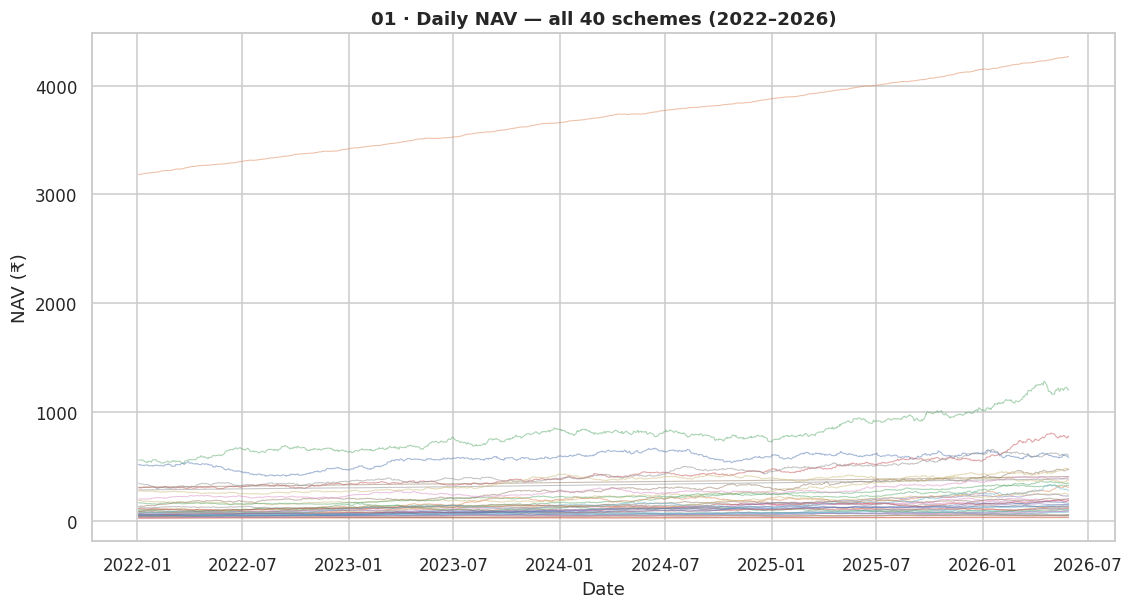

In [ ]:
for c,g in nav.groupby('amfi_code'):
    ax.plot(g.date,g.nav,lw=0.7,alpha=0.5)

## 2. NAV trend — representative Large-Cap schemes

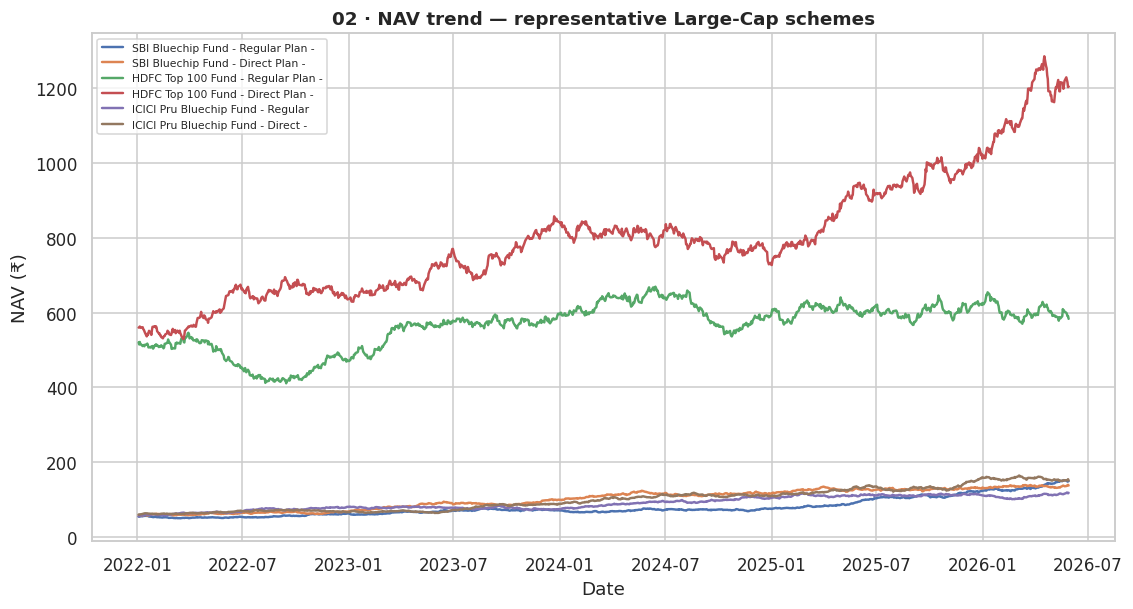

In [ ]:
for c in fm[fm.sub_category=='Large Cap'].amfi_code[:6]:
    g=nav[nav.amfi_code==c]; ax.plot(g.date,g.nav,label=name_of[c])

## 3. AUM growth by fund house (grouped bar, year-end)
**SBI dominates at ₹12.5 lakh crore in 2025.**

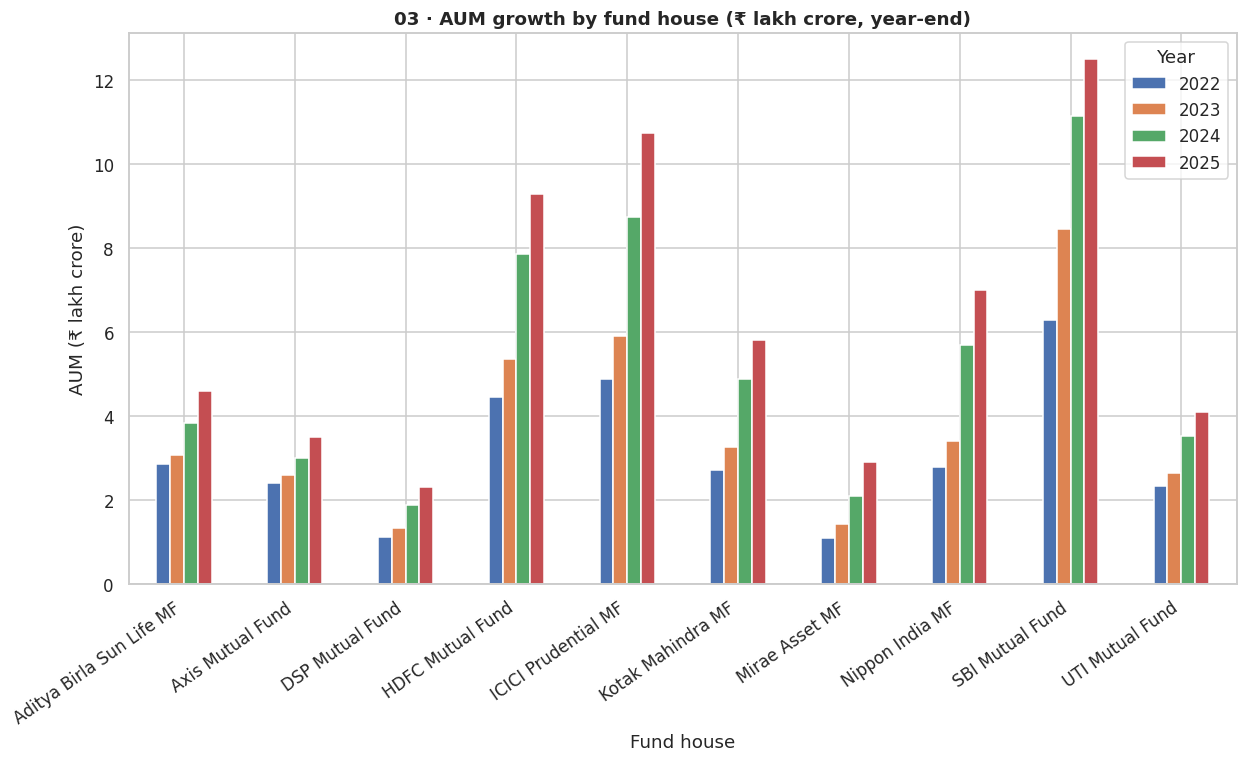

In [ ]:
piv=ye.pivot_table(index='fund_house',columns='year',values='aum_crore')/1e5
piv.plot(kind='bar')

## 4. Monthly SIP inflow trend
**Record ₹31,002 Cr in Dec 2025**, ~2.7× the Jan-2022 level.

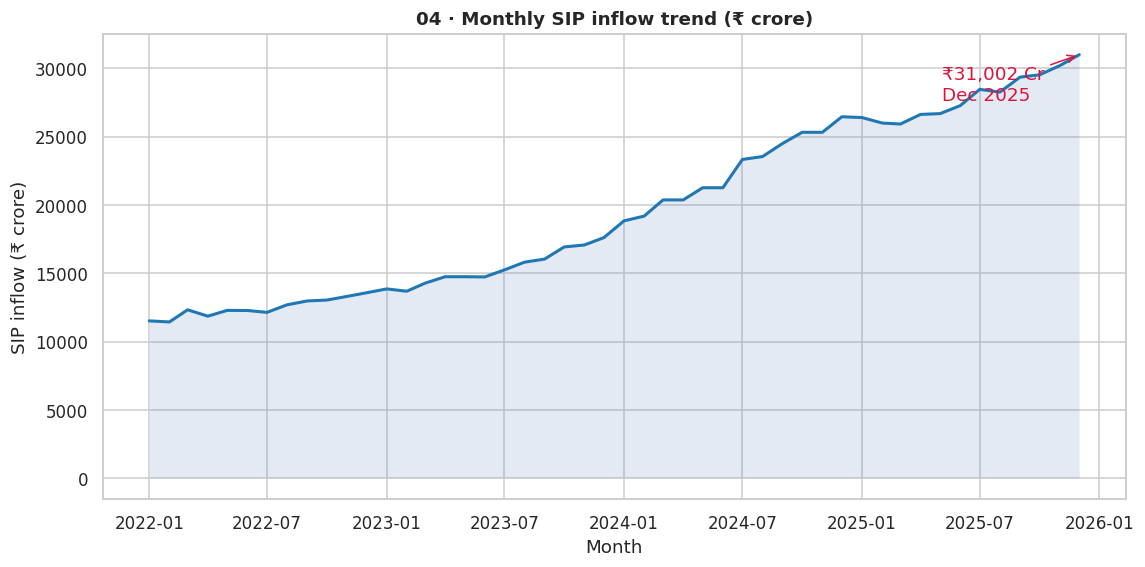

In [ ]:
ax.plot(sip.month,sip.sip_inflow_crore)

## 5. Category-wise net inflow heatmap

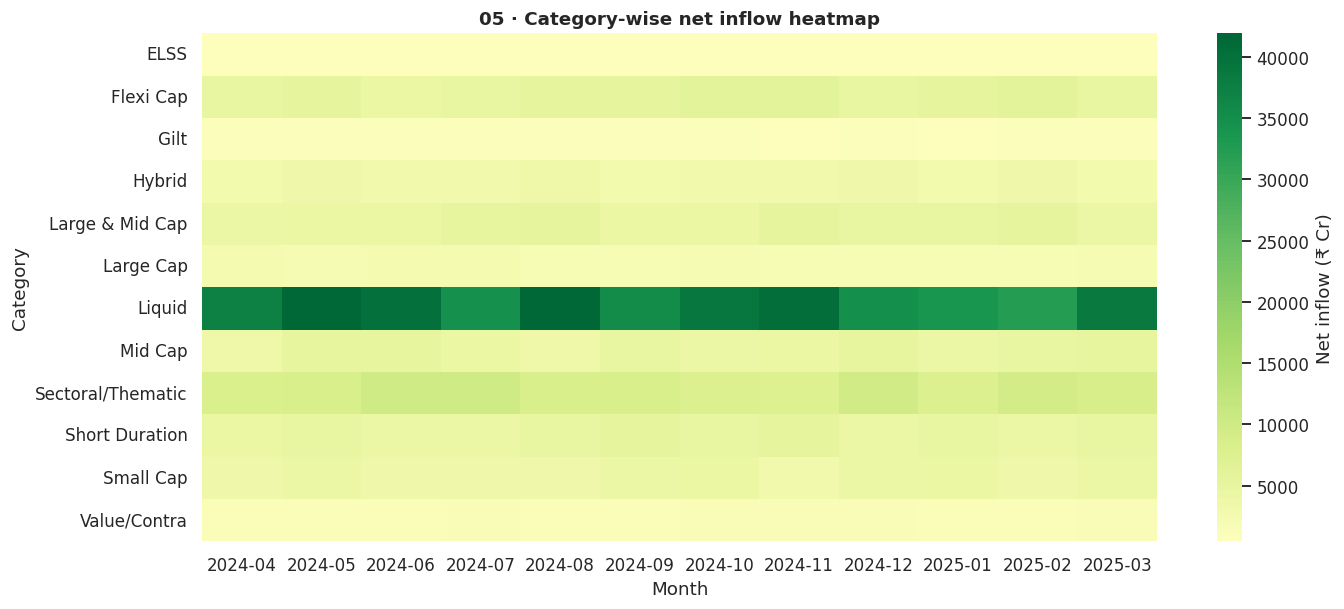

In [ ]:
sns.heatmap(cat.pivot_table(index='category',columns='m',values='net_inflow_crore'),cmap='RdYlGn',center=0)

## 6. Investor age-group distribution
The 26–35 cohort is the largest investor base.

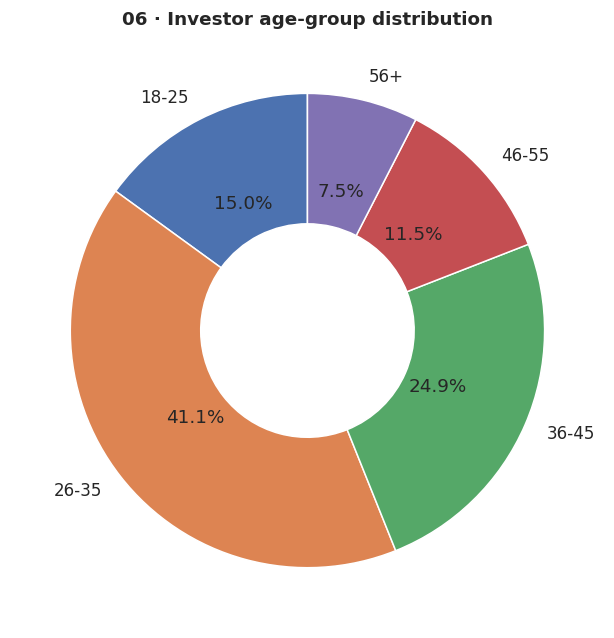

In [ ]:
ag=tx.age_group.value_counts().sort_index(); ax.pie(ag,labels=ag.index,autopct='%1.1f%%',wedgeprops=dict(width=0.55))

## 7. SIP amount distribution by age group

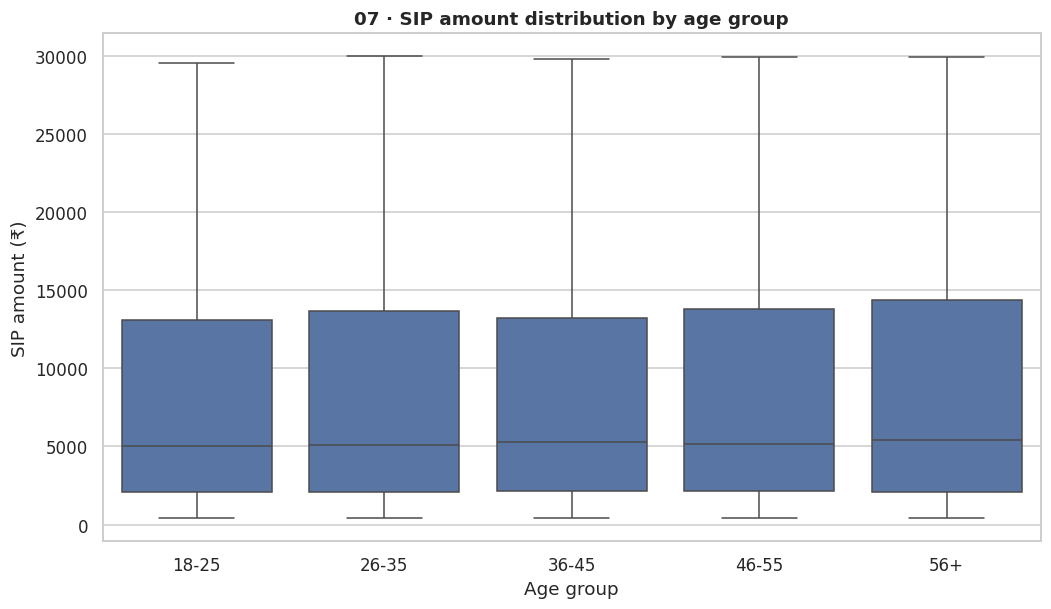

In [ ]:
sns.boxplot(data=sips,x='age_group',y='amount_inr',showfliers=False)

## 8. Total SIP amount by state

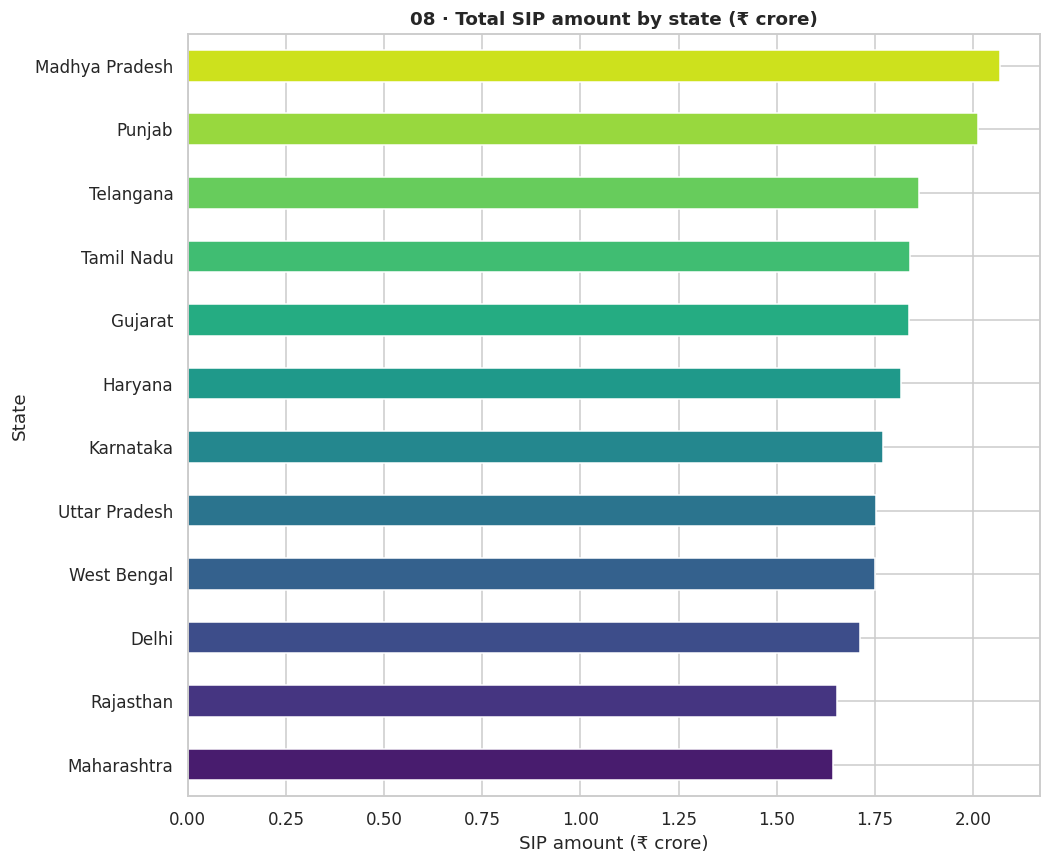

In [ ]:
sips.groupby('state').amount_inr.sum().div(1e7).sort_values().plot(kind='barh')

## 9. Transaction value — T30 vs B30
T30 cities account for 65.9% of value; B30 34.1%.

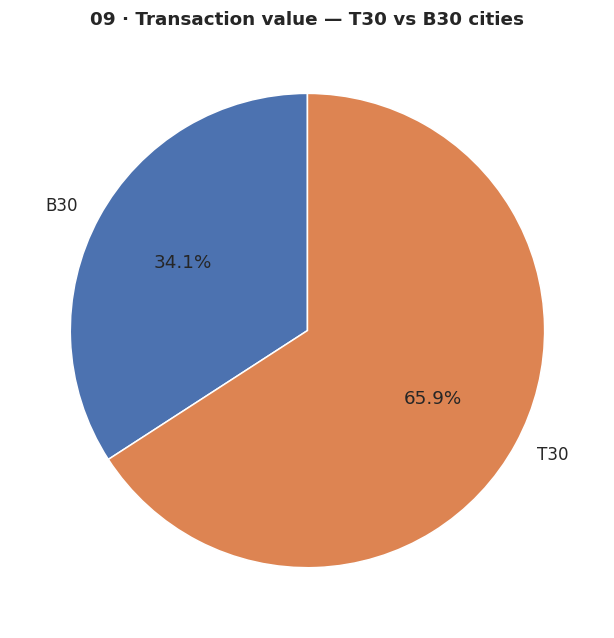

In [ ]:
tier=tx.groupby('city_tier').amount_inr.sum(); ax.pie(tier,labels=tier.index,autopct='%1.1f%%')

## 10. Industry folio count growth
Folios grew 13.26 → 26.12 crore.

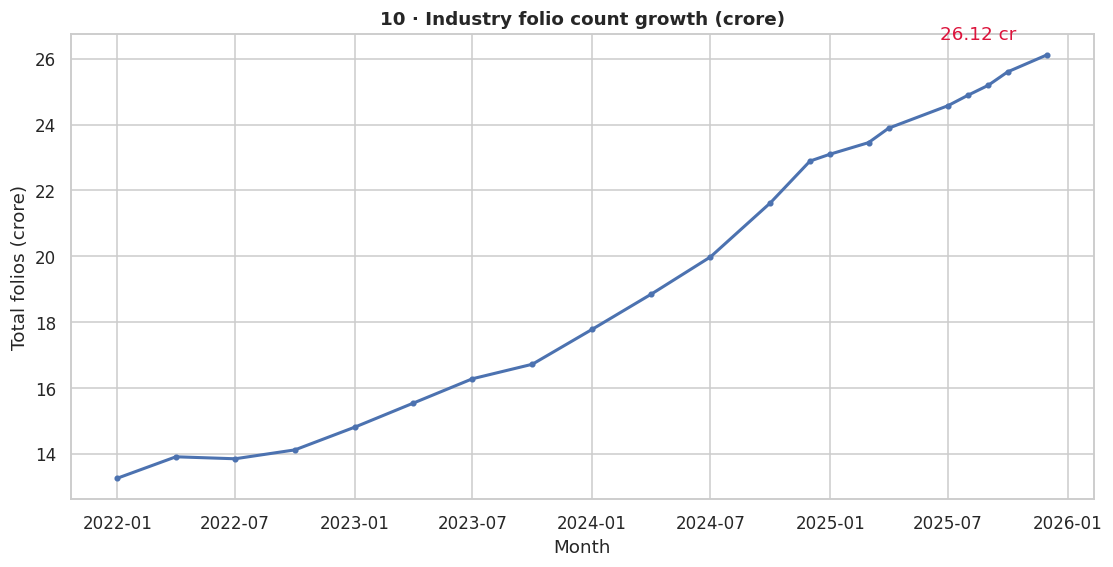

In [ ]:
ax.plot(folio.month,folio.total_folios_crore,marker='o')

## 11. Correlation of daily NAV returns (10 funds)
**All pairwise correlations are ≈0** — unlike real markets where equity funds co-move (~0.7–0.9). This flags that the synthetic NAV series were generated independently.

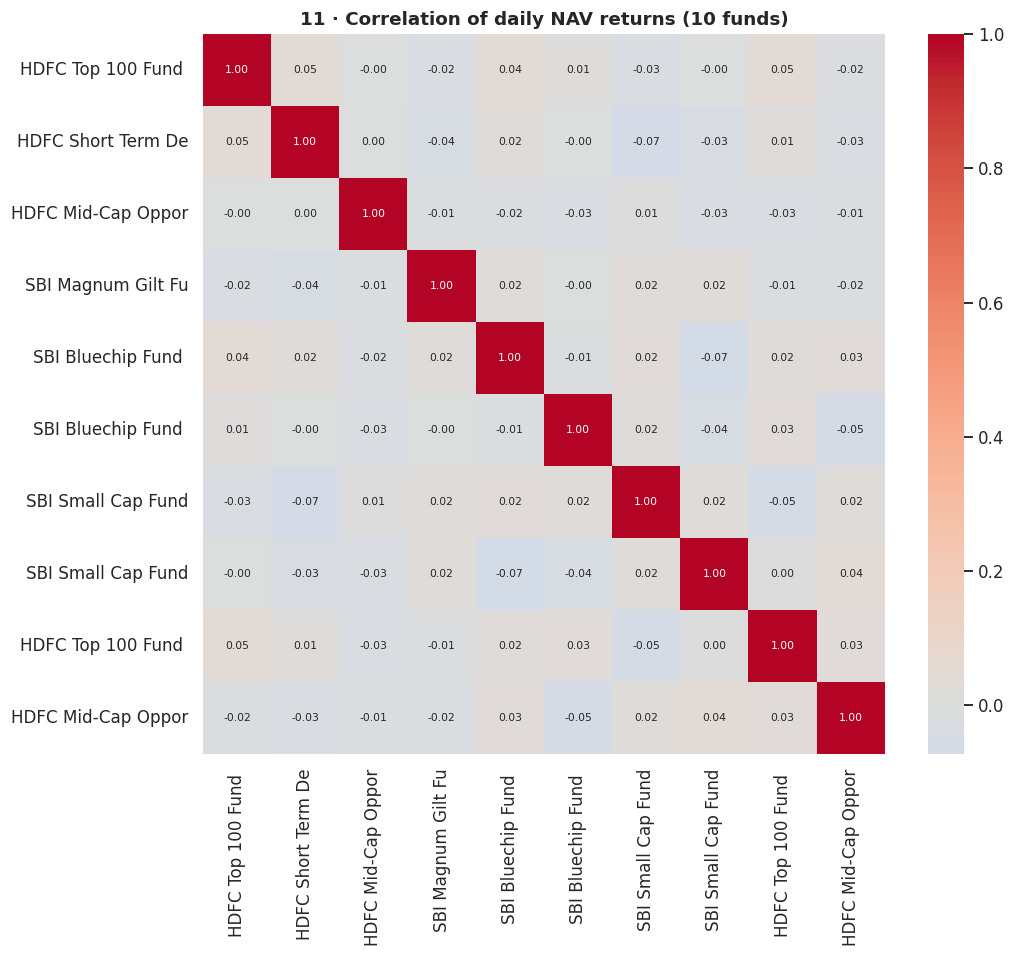

In [ ]:
rets=nav[nav.amfi_code.isin(codes10)].pivot_table(index='date',columns='amfi_code',values='daily_return')
sns.heatmap(rets.corr(),cmap='coolwarm',center=0,annot=True)

## 12. Aggregate portfolio sector allocation
Banking is the largest sector at 19.3%.

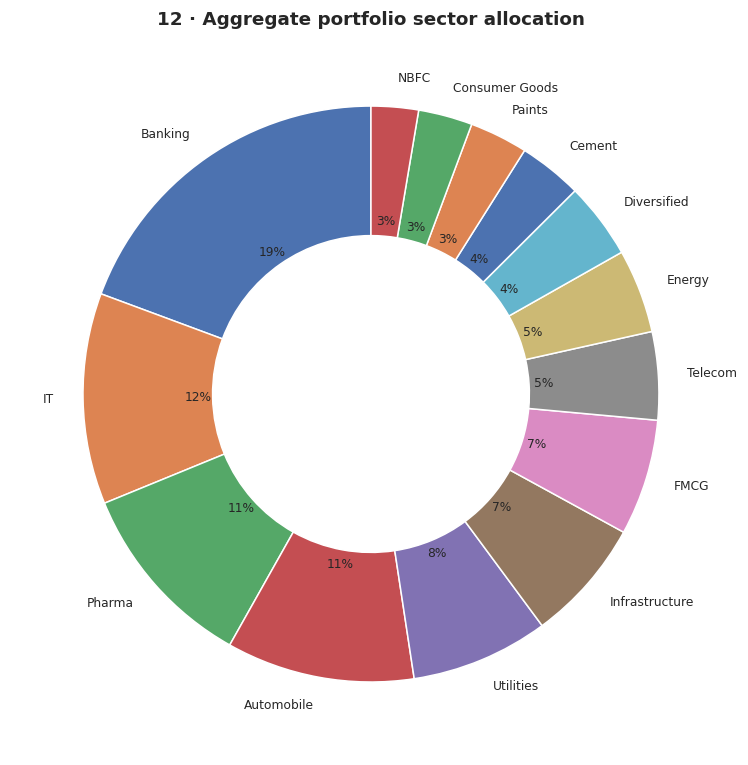

In [ ]:
sec=hold.groupby('sector').market_value_cr.sum().sort_values(ascending=False)
ax.pie(sec,labels=sec.index,autopct='%1.0f%%',wedgeprops=dict(width=0.45))

## 13. Distribution of scheme 1-year returns
Mean 14.4%, range 4.3%–24.9%.

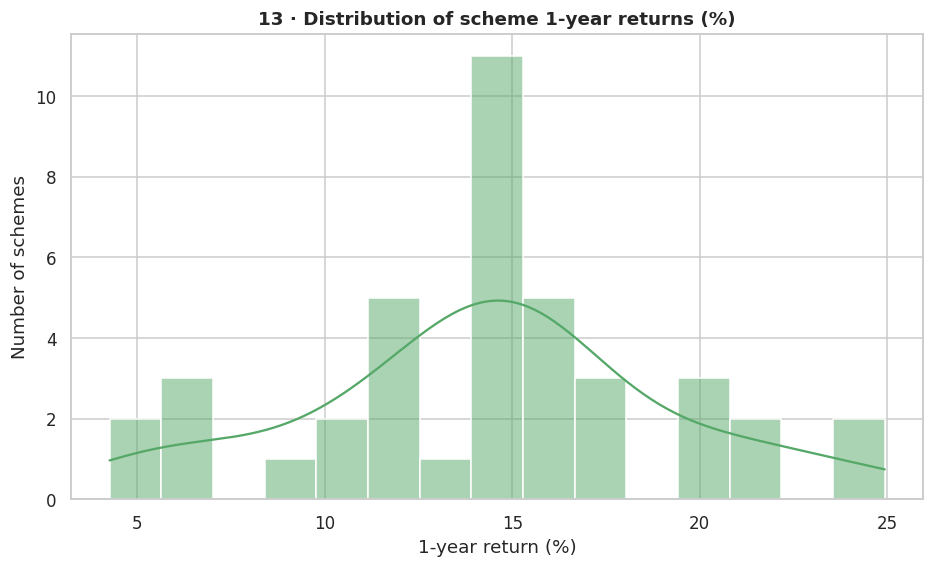

In [ ]:
sns.histplot(perf.return_1yr_pct,bins=15,kde=True)

## 14. Transaction type mix
SIP 60% / Lumpsum 25% / Redemption 15%.

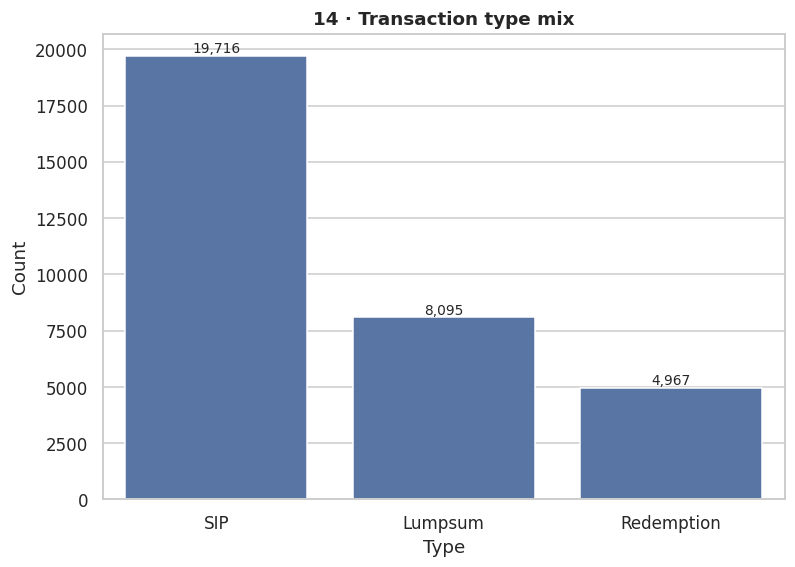

In [ ]:
tx.transaction_type.value_counts().plot(kind='bar')

## 15. Payment mode usage
Nearly even split across Net Banking, Cheque, UPI, Mandate.

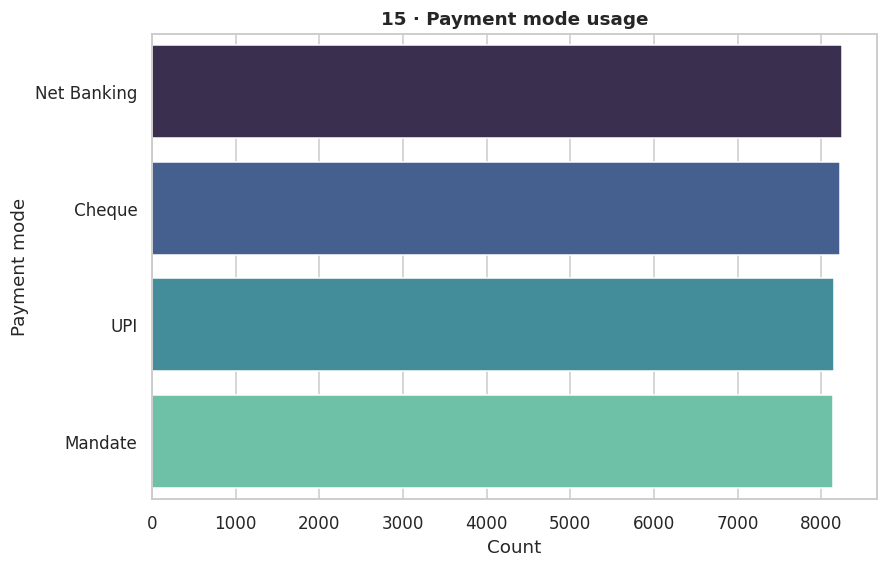

In [ ]:
tx.payment_mode.value_counts().plot(kind='barh')

## 16. Average NAV across all schemes per month

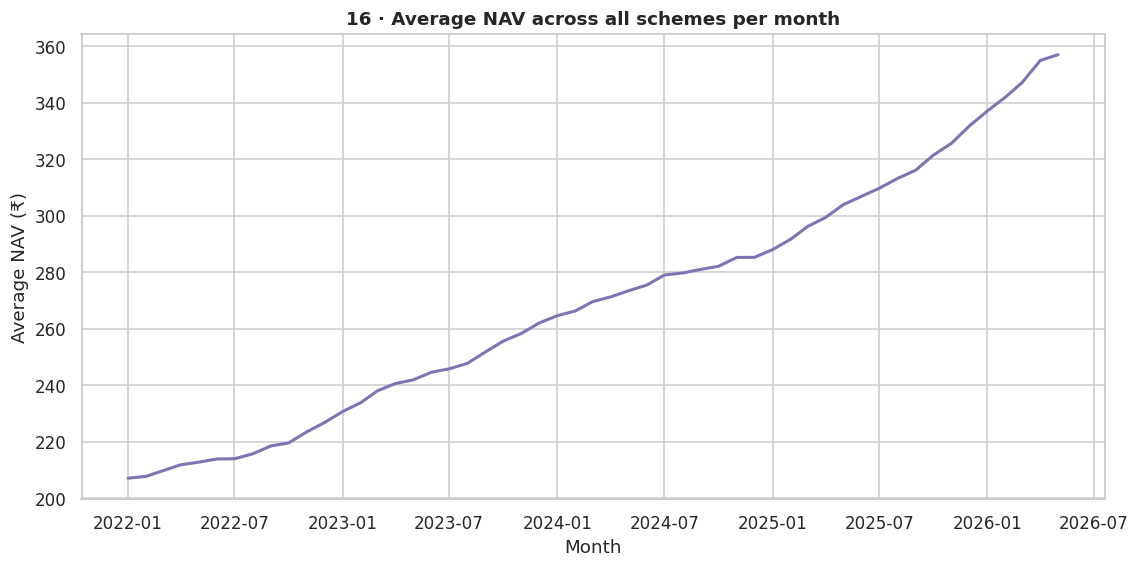

In [ ]:
nav.groupby(nav.date.dt.to_period('M')).nav.mean().plot()

---
# EDA Findings Summary

Exploratory analysis of the Bluestock mutual-fund datasets (40 schemes, 46K NAV
observations, ~33K investor transactions, 2022–2026). All figures below are
computed from `data/processed/`; the 16 supporting charts are in `charts/`.

## 10 key findings

1. **SBI leads the industry on AUM.** Year-end 2025 AUM reaches **₹12.5 lakh crore**
   for SBI Mutual Fund, ahead of ICICI Prudential (₹10.7L cr) and HDFC (₹9.3L cr).
   All ten AMCs roughly doubled AUM over 2022→2025. *(chart 03)*

2. **SIP inflows hit a record ₹31,002 crore in Dec 2025**, up from ₹11,517 crore in
   Jan 2022 — a ~2.7× rise in four years, averaging **31.5% YoY growth**. *(chart 04)*

3. **Retail participation is broadening fast.** Industry folio count grew from
   **13.26 crore to 26.12 crore** (≈97% growth) over the period. *(chart 10)*

4. **Liquid/debt funds dominate net category inflows.** The Liquid category drew
   the largest cumulative net inflow (₹4.5 lakh crore), with equity sub-categories
   (Flexi Cap, Large & Mid Cap, Mid/Small Cap) consistently positive. *(charts 05, 08)*

5. **NAV growth tracks the broad market.** Average NAV across schemes rose steadily
   2022→2026 with visible drawdowns in 2022 and a strong 2023–2024 rally; equity
   schemes show far higher dispersion than debt/liquid. *(charts 01, 02, 16)*

6. **Returns cluster in the mid-teens.** Mean 1-year return is **14.4%** (range
   4.3%–24.9%); the top performer is ABSL Small Cap (**24.9%**). Distribution is
   right-skewed by small/mid-cap outperformers. *(chart 13)*

7. **Risk-adjusted leadership sits with liquid funds.** Highest Sharpe ratios belong
   to liquid funds (ICICI Pru Liquid 7.68) — expected, as they carry minimal
   volatility; among equity, large caps lead (~1.06 Sharpe). *(Day-2 query 6)*

8. **T30 cities drive two-thirds of flows.** T30 contributes **65.9%** of transaction
   value vs **34.1%** for B30 — but B30's share signals meaningful small-town growth.
   *(chart 09)*

9. **Young investors are the core SIP base.** The **26–35 age group** is the largest
   cohort (≈41% of transactions), followed by 36–45; SIP ticket sizes rise with age.
   *(charts 06, 07)*

10. **Banking dominates portfolio allocation.** Banking is the single largest sector
    holding (₹62,840 cr, **19.3%** of aggregate market value), ahead of IT (₹38,477 cr)
    and Pharma (₹34,606 cr) — typical of Indian equity portfolios. *(chart 12)*

## Secondary observations
- **Payment modes are evenly split** across Net Banking, Cheque, UPI and Mandate
  (~25% each) — surprising given the broader UPI shift; worth validating. *(chart 15)*
- **KYC completeness is 92% Verified, 8% Pending** — a small onboarding-friction tail.
- **Transaction mix:** SIP 60% / Lumpsum 25% / Redemption 15%, confirming a
  systematic-investing-led book. *(chart 14)*
- **Return correlations are near-zero across all funds** (|r| < 0.1 on daily
  returns). In real markets equity schemes co-move strongly (~0.7–0.9), so this
  flat correlation structure indicates the NAV series were **generated
  independently** — a synthetic-data artifact to flag before any portfolio /
  diversification modelling. *(chart 11)*

## Data-quality / anomaly notes
- The live mfapi.in AMFI codes from Day 1 are mislabelled vs the provided CSVs
  (see `reports/day1_data_quality.md`); the 10 CSVs themselves are internally
  consistent and were used for all EDA here.
- Even payment-mode split and clean categorical values suggest the dataset is
  synthetically generated — patterns are realistic but unusually smooth.

## Chart index
`01` NAV trend (all) · `02` NAV large-cap · `03` AUM by AMC · `04` SIP trend ·
`05` Category heatmap · `06` Age pie · `07` SIP by age box · `08` SIP by state ·
`09` T30/B30 · `10` Folio growth · `11` Return correlation · `12` Sector donut ·
`13` Return distribution · `14` Txn mix · `15` Payment mode · `16` Avg NAV monthly.